这份项目要求使用 arch 库对全球主要指数进行 GARCH(1,1) 建模。以下是完整的 Python 代码实现，以及对所提问题的详细分析。

[*********************100%***********************]  4 of 4 completed


Ticker     FTSE 100      S&P 500   Nikkei 225  EURO STOXX 50
count   2880.000000  2880.000000  2880.000000    2880.000000
mean       0.012367     0.046709     0.021269       0.029553
std        1.019867     1.128155     1.295035       1.313208
min      -11.511706   -12.765220   -11.153432     -13.240515
25%       -0.459304    -0.386752    -0.627264      -0.576181
50%        0.053454     0.071127     0.060663       0.060309
75%        0.535291     0.574099     0.721858       0.656565
max        8.666425     8.968323     7.731376       9.846568


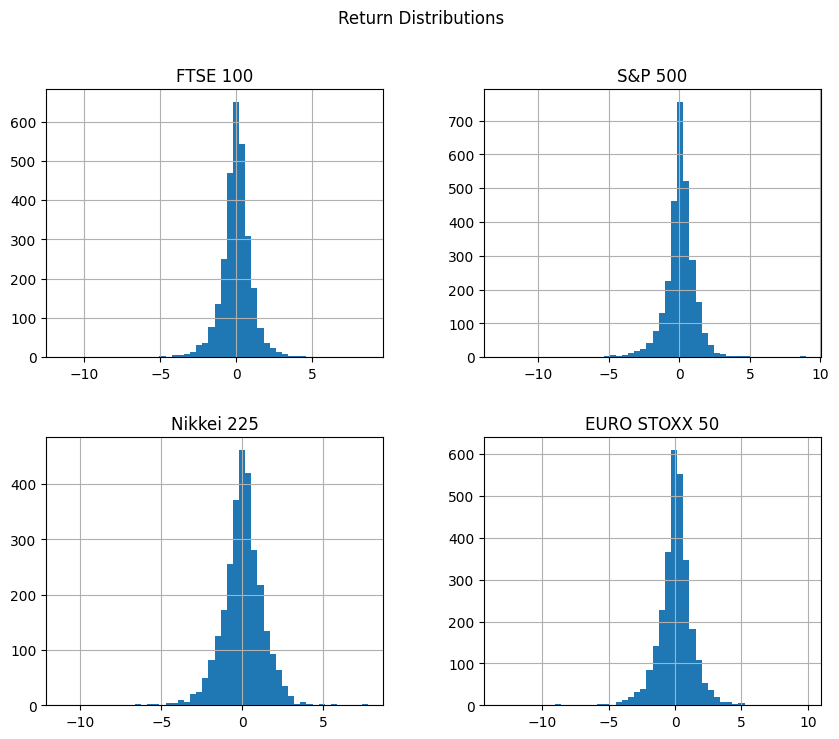


--- FTSE 100 Results ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:               FTSE 100   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3712.78
Distribution:                  Normal   AIC:                           7433.57
Method:            Maximum Likelihood   BIC:                           7457.43
                                        No. Observations:                 2880
Date:                Thu, May 14 2026   Df Residuals:                     2879
Time:                        14:07:15   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0368  1.480e-02

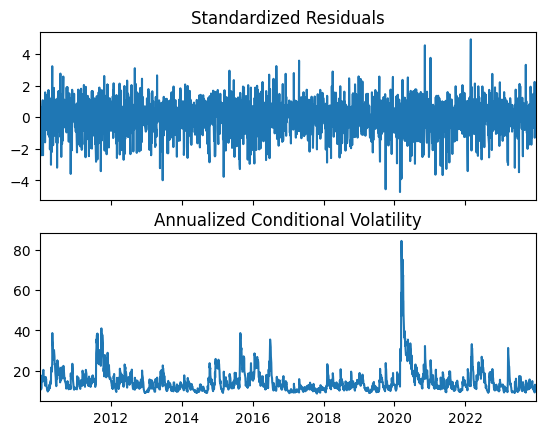


--- S&P 500 Results ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                S&P 500   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3757.90
Distribution:                  Normal   AIC:                           7523.79
Method:            Maximum Likelihood   BIC:                           7547.65
                                        No. Observations:                 2880
Date:                Thu, May 14 2026   Df Residuals:                     2879
Time:                        14:07:15   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0858  1.444e-02      5

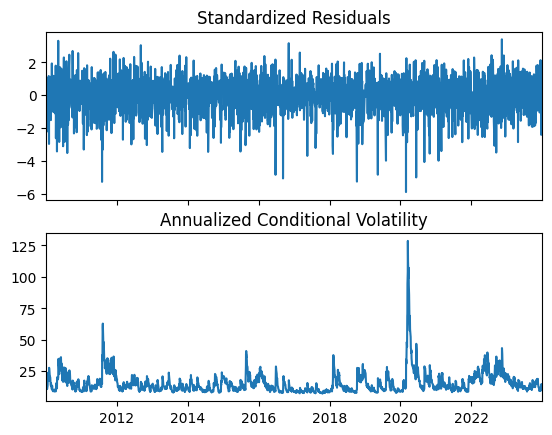


--- Nikkei 225 Results ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Nikkei 225   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4582.49
Distribution:                  Normal   AIC:                           9172.98
Method:            Maximum Likelihood   BIC:                           9196.84
                                        No. Observations:                 2880
Date:                Thu, May 14 2026   Df Residuals:                     2879
Time:                        14:07:15   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0521  2.076e-

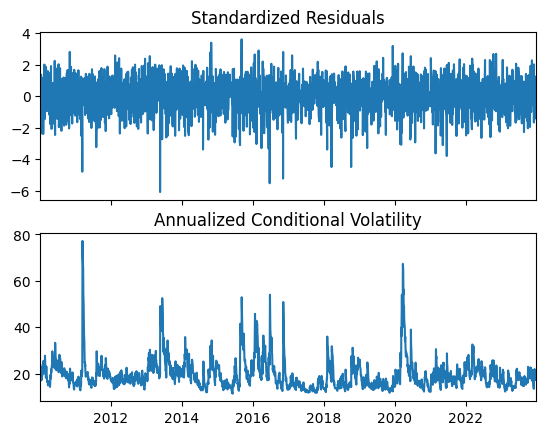


--- EURO STOXX 50 Results ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:          EURO STOXX 50   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4458.72
Distribution:                  Normal   AIC:                           8925.44
Method:            Maximum Likelihood   BIC:                           8949.30
                                        No. Observations:                 2880
Date:                Thu, May 14 2026   Df Residuals:                     2879
Time:                        14:07:15   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0626  1.948e-02 

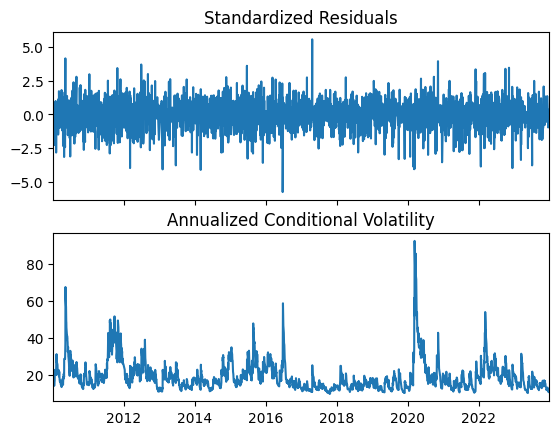


Model Parameters Summary:
                  Omega     Alpha      Beta  Persistence
Ticker                                                  
FTSE 100       0.055987  0.160211  0.782815     0.943026
S&P 500        0.043569  0.197174  0.773530     0.970703
Nikkei 225     0.082793  0.140059  0.815007     0.955067
EURO STOXX 50  0.059909  0.141316  0.826417     0.967733

FTSE 100 - AIC: 7433.57, BIC: 7457.43


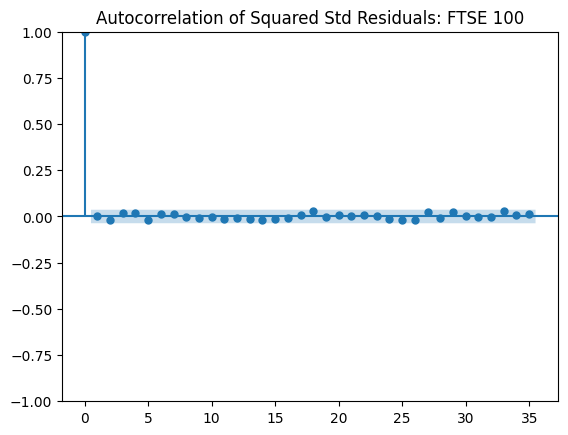


S&P 500 - AIC: 7523.79, BIC: 7547.65


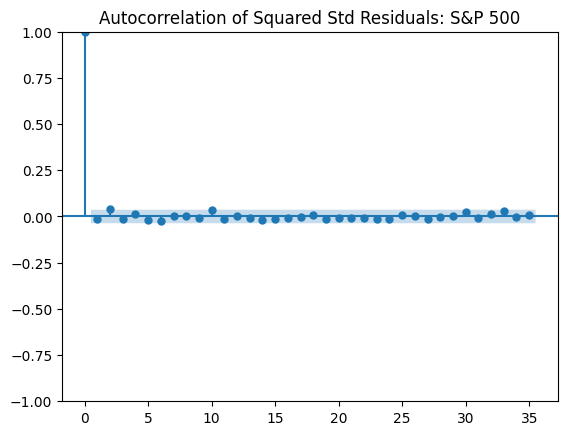


Nikkei 225 - AIC: 9172.98, BIC: 9196.84


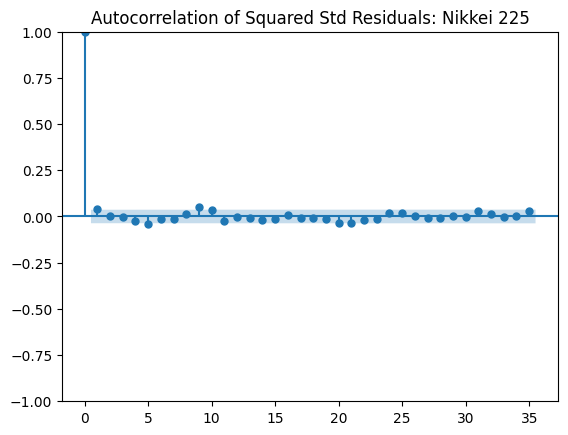


EURO STOXX 50 - AIC: 8925.44, BIC: 8949.30


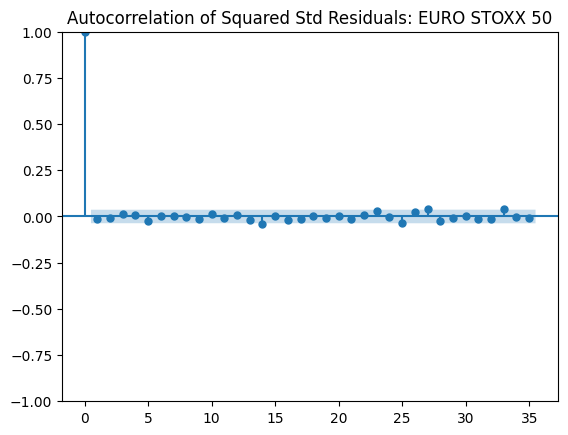

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
import scipy.stats as stats

# 1. 下载数据
tickers = {
    "S&P 500": "^GSPC",
    "EURO STOXX 50": "^STOXX50E",
    "Nikkei 225": "^N225",
    "FTSE 100": "^FTSE",
}
data = yf.download(
    list(tickers.values()), start="2010-01-01", end="2023-12-31", auto_adjust=False
)["Adj Close"]

data.to_csv("../data/data.csv")
data.rename(columns={v: k for k, v in tickers.items()}, inplace=True)

# 2. 计算对数收益率并缩放 (乘以 100 方便 GARCH 收敛)
log_returns = 100 * np.log(data / data.shift(1)).dropna()

# 3. 统计输出 (Output 1 & 2)
print(log_returns.describe())
log_returns.hist(bins=50, figsize=(10, 8))
plt.suptitle("Return Distributions")
plt.show()

# 4. 拟合 GARCH(1,1) (Output 4, 5, 6, 7)
results_summary = {}
for col in log_returns.columns:
    # 定义模型
    model = arch_model(log_returns[col], vol="Garch", p=1, q=1, dist="Normal")
    res = model.fit(disp="off")
    results_summary[col] = res

    # 打印参数
    print(f"\n--- {col} Results ---")
    print(res.summary())

    # 绘制条件波动率 (Output 7)
    res.plot(annualize="D")
    plt.show()

# 5. 生成结果汇总表 (Output 5)
summary_table = pd.DataFrame(
    {
        "Omega": [r.params["omega"] for r in results_summary.values()],
        "Alpha": [r.params["alpha[1]"] for r in results_summary.values()],
        "Beta": [r.params["beta[1]"] for r in results_summary.values()],
        "Persistence": [
            r.params["alpha[1]"] + r.params["beta[1]"] for r in results_summary.values()
        ],
    },
    index=log_returns.columns,
)
print("\nModel Parameters Summary:")
print(summary_table)

# 6. 评估残差与 AIC/BIC (Output 6, 8)
for name, res in results_summary.items():
    print(f"\n{name} - AIC: {res.aic:.2f}, BIC: {res.bic:.2f}")
    # 检查标准化残差是否存在自相关
    from statsmodels.graphics.tsaplots import plot_acf

    plot_acf(res.std_resid**2)
    plt.title(f"Autocorrelation of Squared Std Residuals: {name}")
    plt.show()

问题解答 (Things students should look at)

1. 哪个指数波动率最高？

通过 log_returns.std() 即可对比。通常，新兴市场或特定区域指数的波动率高于美股，这是衡量市场风险大小的核心指标。

2. 哪个指数波动率最持久 (Most persistent)？

观察 Alpha + Beta 的值。该值越接近 1，意味着波动率的“记忆”越长。如果发生冲击，波动率回落到均值的速度越慢，说明市场对冲击的敏感度更持久。

3. 危机期间是否有明显的波动率激增？

观察条件波动率曲线（Conditional Volatility Plot）。你会发现 2020 年疫情期间所有指数都有巨大的 Spike（尖峰）。这是验证 GARCH 模型捕捉“波动率聚集”现象能力的直观证据。



金融数据往往具有“肥尾效应”（Fat-tails）。如果 dist='t' 的 AIC/BIC 值显著小于 dist='Normal'，则证明 t 分布能更好地描述极端波动风险，即考虑了发生黑天鹅事件的概率。

5. 标准化残差是否仍存在自相关？

这是检验模型是否足够好的关键。如果残差平方序列仍有自相关（通过 ACF 图观察），说明 GARCH(1,1) 未能完全提取所有波动率信息，可能需要更高阶的模型（如 GARCH(2,2)）或引入杠杆效应（如 GJR-GARCH）。

6. 不同地区的波动率动态有何不同？

• 欧美市场：通常表现出高度的相关性和相似的波动率聚集结构。

• 日本市场：有时在某些时段（如日元套息交易期间）表现出不同步的波动模式。

• 结论差异：通过对比不同市场的 Persistence（α+β），可以分析不同市场在面临全球系统性风险时，消化情绪的速度是否存在区域性差异。

# End of the notebook